In [1]:
import sys
import os
notebook_dir = os.path.dirname(os.path.abspath(''))
sys.path.insert(0, os.path.abspath(os.path.join(notebook_dir, '..', 'lime_ndt')))
sys.path.insert(0, os.path.abspath(os.path.join(notebook_dir, '..')))

In [16]:
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neural_network import MLPRegressor

# LIME classique (uniquement pour LinearRegression)
from lime.lime_tabular import LimeTabularExplainer as LimeClassicExplainer
# LIME-NDT (gère DecisionTree et NDT)
from lime_ndt.lime_tabular import LimeTabularExplainer as LimeNDTExplainer
from lime_ndt.utils.ndt_sklearn_wrapper import NDTRegressorWrapper

# ========================
# Wrapper pour DecisionTree
# ========================
class DecisionTreeWrapper(DecisionTreeRegressor):
    def fit(self, X, y, sample_weight=None, *args, **kwargs):
        super().fit(X, y, sample_weight=sample_weight, *args, **kwargs)
        self.coef_ = np.array(self.feature_importances_)
        self.intercept_ = 0
        return self

# ========================
# Charger dataset
# ========================
data = fetch_california_housing()
X = data.data
y = data.target
feature_names = data.feature_names

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# ========================
# Modèle global (Random Forest)
# ========================
mlp_global = MLPRegressor(
    hidden_layer_sizes=(256, 128, 64, 32),  # 4 couches cachées avec plus de neurones
    activation='relu',                       # fonction d'activation ReLU
    solver='adam',                           # optimiseur adaptatif
    max_iter=2000,                            # augmenter le nombre d'itérations pour convergence
    learning_rate_init=0.001,                # taux d'apprentissage initial
    random_state=42
)

mlp_global.fit(X_train, y_train)

def predict_fn(X):
    return mlp_global.predict(X)
# ========================
# Explainers
# ========================
explainer_classic = LimeClassicExplainer(
    X_train,
    feature_names=feature_names,
    discretize_continuous=False,
    mode='regression'
)

explainer_ndt = LimeNDTExplainer(
    X_train,
    feature_names=feature_names,
    discretize_continuous=False,
    mode='regression'
)

# ========================
# Fonction pour mesurer la fidélité avec train/test de perturbations
# ========================
def fidelity_local_model(instance, explainer, local_model, predict_fn,
                         num_samples_train=5000, num_samples_test=2000, metric="r2"):
    """
    Calcule la fidélité d'un modèle local par rapport au modèle global
    sur des perturbations différentes pour l'entraînement et le test.
    """
    num_features = instance.shape[0]

    # --- Perturbations pour entraîner le modèle local ---
    Z_train = np.zeros((num_samples_train, num_features))
    for i in range(num_features):
        mean = instance[i]
        std = explainer.scaler.scale_[i] if hasattr(explainer.scaler, "scale_") else 0.01
        Z_train[:, i] = np.random.normal(mean, std, size=num_samples_train)
    y_global_train = predict_fn(Z_train)
    local_model.fit(Z_train, y_global_train)

    # --- Perturbations pour tester la fidélité (nouvelles, non vues) ---
    Z_test = np.zeros((num_samples_test, num_features))
    for i in range(num_features):
        mean = instance[i]
        std = explainer.scaler.scale_[i] if hasattr(explainer.scaler, "scale_") else 0.01
        Z_test[:, i] = np.random.normal(mean, std, size=num_samples_test)
    y_global_test = predict_fn(Z_test)
    y_local_test = local_model.predict(Z_test)

    # Calcul de la fidélité
    if metric == "r2":
        return r2_score(y_global_test, y_local_test)
    elif metric == "mse":
        return mean_squared_error(y_global_test, y_local_test)
    else:
        raise ValueError("metric doit être 'r2' ou 'mse'")

# ========================
# Comparer les 3 modèles sur plusieurs instances du test
# ========================
n_instances = 1
results = {"LinearRegression": [], "DecisionTree": [], "NDT": []}

for idx in range(n_instances):
    instance = X_test[idx]
    results["LinearRegression"].append(
        fidelity_local_model(instance, explainer_classic, LinearRegression(), predict_fn)
    )
    results["DecisionTree"].append(
        fidelity_local_model(instance, explainer_ndt, DecisionTreeWrapper(), predict_fn)
    )
    results["NDT"].append(
        fidelity_local_model(instance, explainer_ndt,
                             NDTRegressorWrapper(D=X_train.shape[1], gammas=[1,1]),
                             predict_fn)
    )

# Moyenne sur toutes les instances
print("=== Fidélité moyenne des modèles locaux (MSE) ===")
for model_name, scores in results.items():
    print(f"{model_name}: {np.mean(scores):.3f}")


mean_leaf_values shape: (32, 1, 1)
self.L: 32 self.C: 1
mean_leaf_values shape after squeeze: (32, 1)


c:\Users\DELL\Desktop\lime_ndt\.venv\lib\site-packages\keras\src\optimizers\base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 914us/step
=== Fidélité moyenne des modèles locaux (MSE) ===
LinearRegression: 0.508
DecisionTree: 0.944
NDT: 0.962


## Diabetes Dataset

In [17]:
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neural_network import MLPRegressor

# LIME classique (uniquement pour LinearRegression)
from lime.lime_tabular import LimeTabularExplainer as LimeClassicExplainer
# LIME-NDT (gère DecisionTree et NDT)
from lime_ndt.lime_tabular import LimeTabularExplainer as LimeNDTExplainer
from lime_ndt.utils.ndt_sklearn_wrapper import NDTRegressorWrapper

# ========================
# Wrapper pour DecisionTree
# ========================
class DecisionTreeWrapper(DecisionTreeRegressor):
    def fit(self, X, y, sample_weight=None, *args, **kwargs):
        super().fit(X, y, sample_weight=sample_weight, *args, **kwargs)
        self.coef_ = np.array(self.feature_importances_)
        self.intercept_ = 0
        return self

# ========================
# Charger dataset
# ========================
data = load_diabetes()
X = data.data
y = data.target
feature_names = data.feature_names

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# ========================
# Modèle global (Random Forest)
# ========================
mlp_global = MLPRegressor(
    hidden_layer_sizes=(256, 128, 64, 32),  # 4 couches cachées avec plus de neurones
    activation='relu',                       # fonction d'activation ReLU
    solver='adam',                           # optimiseur adaptatif
    max_iter=2000,                            # augmenter le nombre d'itérations pour convergence
    learning_rate_init=0.001,                # taux d'apprentissage initial
    random_state=42
)

mlp_global.fit(X_train, y_train)

def predict_fn(X):
    return mlp_global.predict(X)
# ========================
# Explainers
# ========================
explainer_classic = LimeClassicExplainer(
    X_train,
    feature_names=feature_names,
    discretize_continuous=False,
    mode='regression'
)

explainer_ndt = LimeNDTExplainer(
    X_train,
    feature_names=feature_names,
    discretize_continuous=False,
    mode='regression'
)

# ========================
# Fonction pour mesurer la fidélité avec train/test de perturbations
# ========================
def fidelity_local_model(instance, explainer, local_model, predict_fn,
                         num_samples_train=5000, num_samples_test=2000, metric="r2"):
    """
    Calcule la fidélité d'un modèle local par rapport au modèle global
    sur des perturbations différentes pour l'entraînement et le test.
    """
    num_features = instance.shape[0]

    # --- Perturbations pour entraîner le modèle local ---
    Z_train = np.zeros((num_samples_train, num_features))
    for i in range(num_features):
        mean = instance[i]
        std = explainer.scaler.scale_[i] if hasattr(explainer.scaler, "scale_") else 0.01
        Z_train[:, i] = np.random.normal(mean, std, size=num_samples_train)
    y_global_train = predict_fn(Z_train)
    local_model.fit(Z_train, y_global_train)

    # --- Perturbations pour tester la fidélité (nouvelles, non vues) ---
    Z_test = np.zeros((num_samples_test, num_features))
    for i in range(num_features):
        mean = instance[i]
        std = explainer.scaler.scale_[i] if hasattr(explainer.scaler, "scale_") else 0.01
        Z_test[:, i] = np.random.normal(mean, std, size=num_samples_test)
    y_global_test = predict_fn(Z_test)
    y_local_test = local_model.predict(Z_test)

    # Calcul de la fidélité
    if metric == "r2":
        return r2_score(y_global_test, y_local_test)
    elif metric == "mse":
        return mean_squared_error(y_global_test, y_local_test)
    else:
        raise ValueError("metric doit être 'r2' ou 'mse'")

# ========================
# Comparer les 3 modèles sur plusieurs instances du test
# ========================
n_instances = 1
results = {"LinearRegression": [], "DecisionTree": [], "NDT": []}

for idx in range(n_instances):
    instance = X_test[idx]
    results["LinearRegression"].append(
        fidelity_local_model(instance, explainer_classic, LinearRegression(), predict_fn)
    )
    results["DecisionTree"].append(
        fidelity_local_model(instance, explainer_ndt, DecisionTreeWrapper(), predict_fn)
    )
    results["NDT"].append(
        fidelity_local_model(instance, explainer_ndt,
                             NDTRegressorWrapper(D=X_train.shape[1], gammas=[1,1]),
                             predict_fn)
    )

# Moyenne sur toutes les instances
print("=== Fidélité moyenne des modèles locaux (R2) ===")
for model_name, scores in results.items():
    print(f"{model_name}: {np.mean(scores):.3f}")


mean_leaf_values shape: (32, 1, 1)
self.L: 32 self.C: 1
mean_leaf_values shape after squeeze: (32, 1)


c:\Users\DELL\Desktop\lime_ndt\.venv\lib\site-packages\keras\src\optimizers\base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
=== Fidélité moyenne des modèles locaux (R2) ===
LinearRegression: 0.932
DecisionTree: 0.637
NDT: 0.915


## Iris Dataset

In [18]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import r2_score

# LIME classique (uniquement pour LinearRegression)
from lime.lime_tabular import LimeTabularExplainer as LimeClassicExplainer
# LIME-NDT
from lime_ndt.lime_tabular import LimeTabularExplainer as LimeNDTExplainer
from lime_ndt.utils.ndt_sklearn_wrapper import NDTRegressorWrapper

# ========================
# Wrapper pour DecisionTree
# ========================
class DecisionTreeWrapper(DecisionTreeRegressor):
    def fit(self, X, y, sample_weight=None, *args, **kwargs):
        super().fit(X, y, sample_weight=sample_weight, *args, **kwargs)
        self.coef_ = np.array(self.feature_importances_)
        self.intercept_ = 0
        return self

# ========================
# Charger dataset Iris
# ========================
data = load_iris()
X = data.data
y = data.target.astype(float)  # convert to float pour la régression
feature_names = data.feature_names

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# ========================
# Modèle global (MLPClassifier)
# ========================
mlp_global = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    max_iter=2000,
    random_state=42
)
mlp_global.fit(X_train, y_train)

def predict_fn(X):
    # retourner les labels comme float pour la fidélité locale
    return mlp_global.predict(X).astype(float)

# ========================
# Explainers
# ========================
explainer_classic = LimeClassicExplainer(
    X_train,
    feature_names=feature_names,
    discretize_continuous=False,
    mode='classification'  # pour LinearRegression local
)

explainer_ndt = LimeNDTExplainer(
    X_train,
    feature_names=feature_names,
    discretize_continuous=False,
    mode='classification'  # on utilise regressor wrapper
)

# ========================
# Fonction fidélité locale
# ========================
def fidelity_local_model(instance, explainer, local_model, predict_fn,
                         num_samples_train=5000, num_samples_test=2000, metric="r2"):
    num_features = instance.shape[0]

    # --- Train perturbations ---
    Z_train = np.zeros((num_samples_train, num_features))
    for i in range(num_features):
        mean = instance[i]
        std = explainer.scaler.scale_[i] if hasattr(explainer.scaler, "scale_") else 0.01
        Z_train[:, i] = np.random.normal(mean, std, size=num_samples_train)
    y_global_train = predict_fn(Z_train)
    local_model.fit(Z_train, y_global_train)

    # --- Test perturbations ---
    Z_test = np.zeros((num_samples_test, num_features))
    for i in range(num_features):
        mean = instance[i]
        std = explainer.scaler.scale_[i] if hasattr(explainer.scaler, "scale_") else 0.01
        Z_test[:, i] = np.random.normal(mean, std, size=num_samples_test)
    y_global_test = predict_fn(Z_test)
    y_local_test = local_model.predict(Z_test)

    if metric == "r2":
        return r2_score(y_global_test, y_local_test)
    elif metric == "mse":
        from sklearn.metrics import mean_squared_error
        return mean_squared_error(y_global_test, y_local_test)

# ========================
# Comparer les modèles locaux
# ========================
n_instances = 1
results = {"LinearRegression": [], "DecisionTree": [], "NDT": []}

for idx in range(n_instances):
    instance = X_test[idx]
    results["LinearRegression"].append(
        fidelity_local_model(instance, explainer_classic, LinearRegression(), predict_fn)
    )
    results["DecisionTree"].append(
        fidelity_local_model(instance, explainer_ndt, DecisionTreeWrapper(), predict_fn)
    )
    results["NDT"].append(
        fidelity_local_model(instance, explainer_ndt,
                             NDTRegressorWrapper(D=X_train.shape[1], gammas=[1,1]),
                             predict_fn)
    )

print("=== Fidélité moyenne des modèles locaux (R²) ===")
for model_name, scores in results.items():
    print(f"{model_name}: {np.mean(scores):.3f}")


mean_leaf_values shape: (32, 1, 1)
self.L: 32 self.C: 1
mean_leaf_values shape after squeeze: (32, 1)


c:\Users\DELL\Desktop\lime_ndt\.venv\lib\site-packages\keras\src\optimizers\base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
=== Fidélité moyenne des modèles locaux (R²) ===
LinearRegression: 0.743
DecisionTree: 0.803
NDT: 0.876


## Wine Dataset

In [19]:
import numpy as np
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import r2_score

# LIME classique (uniquement pour LinearRegression)
from lime.lime_tabular import LimeTabularExplainer as LimeClassicExplainer
# LIME-NDT
from lime_ndt.lime_tabular import LimeTabularExplainer as LimeNDTExplainer
from lime_ndt.utils.ndt_sklearn_wrapper import NDTRegressorWrapper

# ========================
# Wrapper pour DecisionTree
# ========================
class DecisionTreeWrapper(DecisionTreeRegressor):
    def fit(self, X, y, sample_weight=None, *args, **kwargs):
        super().fit(X, y, sample_weight=sample_weight, *args, **kwargs)
        self.coef_ = np.array(self.feature_importances_)
        self.intercept_ = 0
        return self

# ========================
# Charger dataset Iris
# ========================
data = load_wine()
X = data.data
y = data.target.astype(float)  # convert to float pour la régression
feature_names = data.feature_names

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# ========================
# Modèle global (MLPClassifier)
# ========================
mlp_global = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    max_iter=2000,
    random_state=42
)
mlp_global.fit(X_train, y_train)

def predict_fn(X):
    # retourner les labels comme float pour la fidélité locale
    return mlp_global.predict(X).astype(float)

# ========================
# Explainers
# ========================
explainer_classic = LimeClassicExplainer(
    X_train,
    feature_names=feature_names,
    discretize_continuous=False,
    mode='classification'  # pour LinearRegression local
)

explainer_ndt = LimeNDTExplainer(
    X_train,
    feature_names=feature_names,
    discretize_continuous=False,
    mode='classification'  # on utilise regressor wrapper
)

# ========================
# Fonction fidélité locale
# ========================
def fidelity_local_model(instance, explainer, local_model, predict_fn,
                         num_samples_train=5000, num_samples_test=2000, metric="r2"):
    num_features = instance.shape[0]

    # --- Train perturbations ---
    Z_train = np.zeros((num_samples_train, num_features))
    for i in range(num_features):
        mean = instance[i]
        std = explainer.scaler.scale_[i] if hasattr(explainer.scaler, "scale_") else 0.01
        Z_train[:, i] = np.random.normal(mean, std, size=num_samples_train)
    y_global_train = predict_fn(Z_train)
    local_model.fit(Z_train, y_global_train)

    # --- Test perturbations ---
    Z_test = np.zeros((num_samples_test, num_features))
    for i in range(num_features):
        mean = instance[i]
        std = explainer.scaler.scale_[i] if hasattr(explainer.scaler, "scale_") else 0.01
        Z_test[:, i] = np.random.normal(mean, std, size=num_samples_test)
    y_global_test = predict_fn(Z_test)
    y_local_test = local_model.predict(Z_test)

    if metric == "r2":
        return r2_score(y_global_test, y_local_test)
    elif metric == "mse":
        from sklearn.metrics import mean_squared_error
        return mean_squared_error(y_global_test, y_local_test)

# ========================
# Comparer les modèles locaux
# ========================
n_instances = 1
results = {"LinearRegression": [], "DecisionTree": [], "NDT": []}

for idx in range(n_instances):
    instance = X_test[idx]
    results["LinearRegression"].append(
        fidelity_local_model(instance, explainer_classic, LinearRegression(), predict_fn)
    )
    results["DecisionTree"].append(
        fidelity_local_model(instance, explainer_ndt, DecisionTreeWrapper(), predict_fn)
    )
    results["NDT"].append(
        fidelity_local_model(instance, explainer_ndt,
                             NDTRegressorWrapper(D=X_train.shape[1], gammas=[1,1]),
                             predict_fn)
    )

print("=== Fidélité moyenne des modèles locaux (R²) ===")
for model_name, scores in results.items():
    print(f"{model_name}: {np.mean(scores):.3f}")


mean_leaf_values shape: (30, 1, 1)
self.L: 30 self.C: 1
mean_leaf_values shape after squeeze: (30, 1)


c:\Users\DELL\Desktop\lime_ndt\.venv\lib\site-packages\keras\src\optimizers\base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
=== Fidélité moyenne des modèles locaux (R²) ===
LinearRegression: 0.369
DecisionTree: 0.250
NDT: 0.364


## Breast Cancer Dataset

In [20]:
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import r2_score

# LIME classique (uniquement pour LinearRegression)
from lime.lime_tabular import LimeTabularExplainer as LimeClassicExplainer
# LIME-NDT
from lime_ndt.lime_tabular import LimeTabularExplainer as LimeNDTExplainer
from lime_ndt.utils.ndt_sklearn_wrapper import NDTRegressorWrapper

# ========================
# Wrapper pour DecisionTree
# ========================
class DecisionTreeWrapper(DecisionTreeRegressor):
    def fit(self, X, y, sample_weight=None, *args, **kwargs):
        super().fit(X, y, sample_weight=sample_weight, *args, **kwargs)
        self.coef_ = np.array(self.feature_importances_)
        self.intercept_ = 0
        return self

# ========================
# Charger dataset Iris
# ========================
data = load_breast_cancer()
X = data.data
y = data.target.astype(float)  # convert to float pour la régression
feature_names = data.feature_names

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# ========================
# Modèle global (MLPClassifier)
# ========================
mlp_global = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    max_iter=2000,
    random_state=42
)
mlp_global.fit(X_train, y_train)

def predict_fn(X):
    # retourner les labels comme float pour la fidélité locale
    return mlp_global.predict(X).astype(float)

# ========================
# Explainers
# ========================
explainer_classic = LimeClassicExplainer(
    X_train,
    feature_names=feature_names,
    discretize_continuous=False,
    mode='classification' 
)

explainer_ndt = LimeNDTExplainer(
    X_train,
    feature_names=feature_names,
    discretize_continuous=False,
    mode='classification'
)

# ========================
# Fonction fidélité locale
# ========================
def fidelity_local_model(instance, explainer, local_model, predict_fn,
                         num_samples_train=5000, num_samples_test=2000, metric="r2"):
    num_features = instance.shape[0]

    # --- Train perturbations ---
    Z_train = np.zeros((num_samples_train, num_features))
    for i in range(num_features):
        mean = instance[i]
        std = explainer.scaler.scale_[i] if hasattr(explainer.scaler, "scale_") else 0.01
        Z_train[:, i] = np.random.normal(mean, std, size=num_samples_train)
    y_global_train = predict_fn(Z_train)
    local_model.fit(Z_train, y_global_train)

    # --- Test perturbations ---
    Z_test = np.zeros((num_samples_test, num_features))
    for i in range(num_features):
        mean = instance[i]
        std = explainer.scaler.scale_[i] if hasattr(explainer.scaler, "scale_") else 0.01
        Z_test[:, i] = np.random.normal(mean, std, size=num_samples_test)
    y_global_test = predict_fn(Z_test)
    y_local_test = local_model.predict(Z_test)

    if metric == "r2":
        return r2_score(y_global_test, y_local_test)
    elif metric == "mse":
        from sklearn.metrics import mean_squared_error
        return mean_squared_error(y_global_test, y_local_test)

# ========================
# Comparer les modèles locaux
# ========================
n_instances = 1
results = {"LinearRegression": [], "DecisionTree": [], "NDT": []}

for idx in range(n_instances):
    instance = X_test[idx]
    results["LinearRegression"].append(
        fidelity_local_model(instance, explainer_classic, LinearRegression(), predict_fn)
    )
    results["DecisionTree"].append(
        fidelity_local_model(instance, explainer_ndt, DecisionTreeWrapper(), predict_fn)
    )
    results["NDT"].append(
        fidelity_local_model(instance, explainer_ndt,
                             NDTRegressorWrapper(D=X_train.shape[1], gammas=[1,1]),
                             predict_fn)
    )

print("=== Fidélité moyenne des modèles locaux (R²) ===")
for model_name, scores in results.items():
    print(f"{model_name}: {np.mean(scores):.3f}")


mean_leaf_values shape: (32, 1, 1)
self.L: 32 self.C: 1
mean_leaf_values shape after squeeze: (32, 1)


c:\Users\DELL\Desktop\lime_ndt\.venv\lib\site-packages\keras\src\optimizers\base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
=== Fidélité moyenne des modèles locaux (R²) ===
LinearRegression: 0.566
DecisionTree: 0.702
NDT: 0.888


## Fidelity Landscape

c:\Users\DELL\Desktop\lime_ndt\.venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\DELL\Desktop\lime_ndt\.venv\lib\site-packages\keras\src\optimizers\base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


mean_leaf_values shape: (31, 1, 1)
self.L: 31 self.C: 1
mean_leaf_values shape after squeeze: (31, 1)
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
mean_leaf_values shape: (31, 1, 1)
self.L: 31 self.C: 1
mean_leaf_values shape after squeeze: (31, 1)


c:\Users\DELL\Desktop\lime_ndt\.venv\lib\site-packages\keras\src\optimizers\base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
mean_leaf_values shape: (31, 1, 1)
self.L: 31 self.C: 1
mean_leaf_values shape after squeeze: (31, 1)


c:\Users\DELL\Desktop\lime_ndt\.venv\lib\site-packages\keras\src\optimizers\base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


...

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
mean_leaf_values shape: (31, 1, 1)
self.L: 31 self.C: 1
mean_leaf_values shape after squeeze: (31, 1)


c:\Users\DELL\Desktop\lime_ndt\.venv\lib\site-packages\keras\src\optimizers\base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
mean_leaf_values shape: (31, 1, 1)
self.L: 31 self.C: 1
mean_leaf_values shape after squeeze: (31, 1)


c:\Users\DELL\Desktop\lime_ndt\.venv\lib\site-packages\keras\src\optimizers\base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


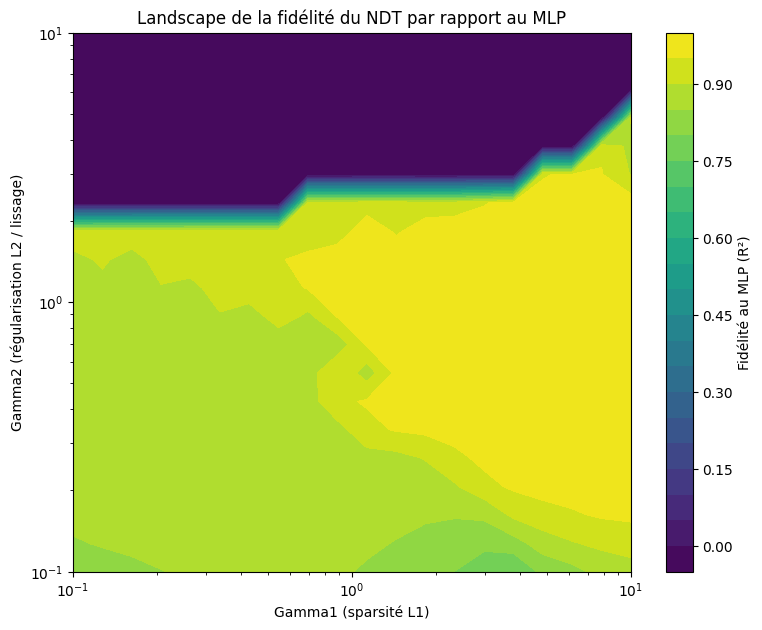

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.neural_network import MLPRegressor
from lime_ndt.utils.ndt_sklearn_wrapper import NDTRegressorWrapper

# ========================
# Charger dataset
# ========================
data = load_diabetes()
X = data.data
y = data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# ========================
# Modèle global (MLP)
# ========================
mlp_global = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    max_iter=2000,
    random_state=42
)
mlp_global.fit(X_train, y_train)

def predict_fn(X):
    return mlp_global.predict(X)

# ========================
# Grille fine de gammas
# ========================
gamma1_values = np.logspace(-1, 1, 20)   # de 0.1 à 10
gamma2_values = np.logspace(-1, 1, 20)

scores = np.zeros((len(gamma2_values), len(gamma1_values)))

for i, g2 in enumerate(gamma2_values):
    for j, g1 in enumerate(gamma1_values):
        model = NDTRegressorWrapper(D=X_train.shape[1], gammas=[g1, g2], epochs=500)
        model.fit(X_train, predict_fn(X_train))
        y_pred = model.predict(X_test)
        scores[i, j] = r2_score(predict_fn(X_test), y_pred)

# ========================
# Landscape (contour plot)
# ========================
plt.figure(figsize=(9,7))
cs = plt.contourf(gamma1_values, gamma2_values, scores, levels=20, cmap="viridis")
plt.colorbar(cs, label="Fidélité au MLP (R²)")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Gamma1 (sparsité L1)")
plt.ylabel("Gamma2 (régularisation L2 / lissage)")
plt.title("Landscape de la fidélité du NDT par rapport au MLP")
plt.show()



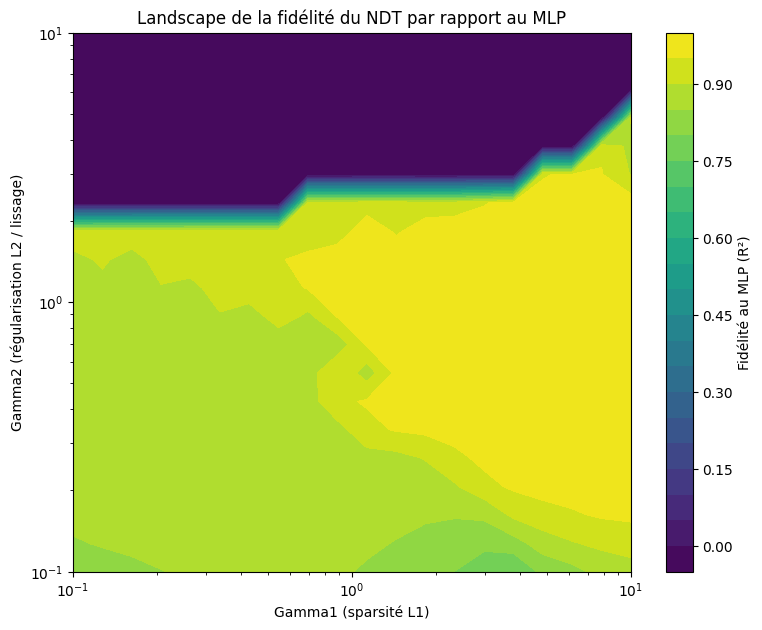

In [10]:
plt.figure(figsize=(9,7))
cs = plt.contourf(gamma1_values, gamma2_values, scores, levels=20, cmap="viridis")
plt.colorbar(cs, label="Fidélité au MLP (R²)")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Gamma1 (sparsité L1)")
plt.ylabel("Gamma2 (régularisation L2 / lissage)")
plt.title("Landscape de la fidélité du NDT par rapport au MLP")
plt.show()

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.neural_network import MLPRegressor
from lime_ndt.utils.ndt_sklearn_wrapper import NDTRegressorWrapper
from joblib import Parallel, delayed

# ========================
# Charger dataset
# ========================
data = load_diabetes()
X = data.data
y = data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# ========================
# Modèle global (MLP)
# ========================
mlp_global = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    max_iter=2000,
    random_state=42
)
mlp_global.fit(X_train, y_train)

def predict_fn(X):
    return mlp_global.predict(X)

# ========================
# Grille fine de gammas (0.1 à 100)
# ========================
gamma1_values = np.logspace(-1, 2, 20)   # de 0.1 à 100
gamma2_values = np.logspace(-1, 2, 20)

# ========================
# Fonction pour un seul modèle
# ========================
def evaluate_gammas(g1, g2):
    model = NDTRegressorWrapper(D=X_train.shape[1], gammas=[g1, g2], epochs=500)
    model.fit(X_train, predict_fn(X_train))
    y_pred = model.predict(X_test)
    score = r2_score(predict_fn(X_test), y_pred)
    return score

# ========================
# Calcul parallèle
# ========================
scores = Parallel(n_jobs=-1)(
    delayed(evaluate_gammas)(g1, g2)
    for g2 in gamma2_values
    for g1 in gamma1_values
)

# Reshape scores pour contour plot
scores = np.array(scores).reshape(len(gamma2_values), len(gamma1_values))

# ========================
# Landscape (contour plot)
# ========================
plt.figure(figsize=(9,7))
cs = plt.contourf(gamma1_values, gamma2_values, scores, levels=20, cmap="viridis")
plt.colorbar(cs, label="Fidélité au MLP (R²)")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Gamma1 (sparsité L1)")
plt.ylabel("Gamma2 (régularisation L2 / lissage)")
plt.title("Landscape de la fidélité du NDT par rapport au MLP")
plt.show()


c:\Users\DELL\Desktop\lime_ndt\.venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(


KeyboardInterrupt: 